~o~ This Study: L-Band  ( GBT )  ~o~
SEFD : 10.04512371172085
Sens : 22.60454168760974
Max Distance (m) : 9.010168103403985e+23
EIRP : 2.3060640076240506e+24
EIRP (max drift rate) : 6.918192022872152e+25
BeamSize : 0.015329777696809932
Sky Coverage : 1.4869884365905635
CWTFM : 44.87204248957135
DFM : 9131833.149749747
~o~ This Study: S-Band  ( GBT )  ~o~
SEFD : 11.37462537944861
Sens : 25.596319263911028
EIRP : 2.6112783615742925e+24
EIRP (max drift rate) : 1.5667670169445756e+26
Max Distance (m) : 9.010168103403985e+23
BeamSize : 0.006520226808662067
Sky Coverage : 0.6324620004402205
CWTFM : 55.462657280777854
DFM : 4590880.763472115
~o~ This Study: C-Band  ( GBT )  ~o~
SEFD : 13.522281919624222
Sens : 30.429190733320805
Max Distance (m) : 9.010168103403985e+23
EIRP : 3.104316933340068e+24
EIRP (max drift rate) : 3.725180320008082e+26
BeamSize : 0.0009908646888199468
Sky Coverage : 0.09611387481553484
CWTFM : 48.19860501764843
DFM : 2175875.6852965537
~o~ This Study: 4-Band  ( GBT )  

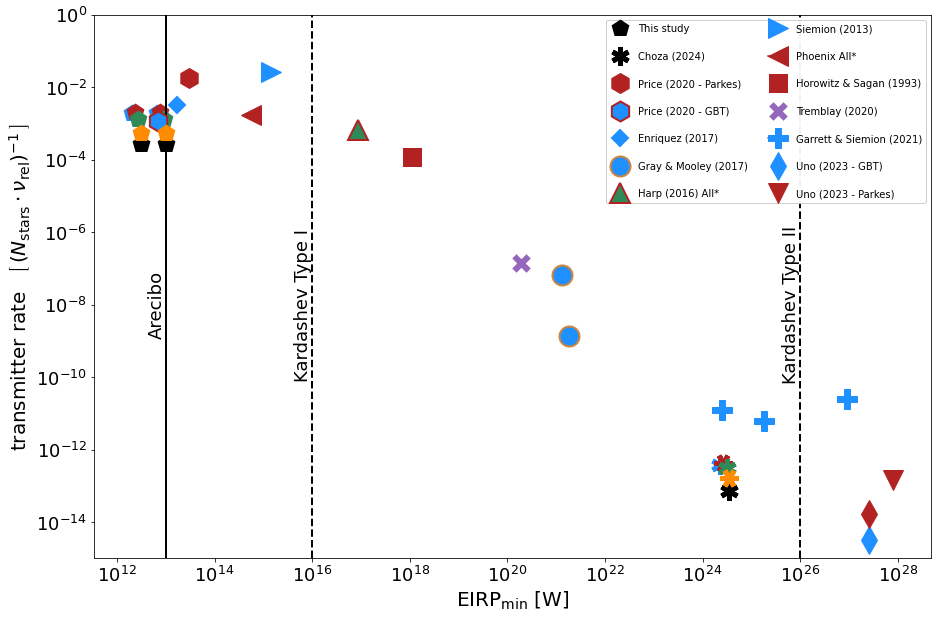

In [1]:
import os
import matplotlib.pyplot as plt

wd = 'seti_limits_py3'
if os.getcwd().find(wd) == -1:
    os.chdir(wd)

from color_coded_ET_power_law import *

from LBand_SETI_compare import lband_compare
from SBand_SETI_compare import sband_compare 
from CBand_SETI_compare import cband_compare
from XBand_SETI_compare import xband_compare
from LBand_SETI_compare_nearby_stars import lband_compare as lband_j25
from SBand_SETI_compare_nearby_stars import sband_compare as sband_j25 
from CBand_SETI_compare_nearby_stars import cband_compare as cband_j25
from XBand_SETI_compare_nearby_stars import xband_compare as xband_j25
import numpy as np

def seti_compare(y_label_units=True):
    ''' Compare SETI project with previous surveys.
    ''' 

    ldist = 2.92e7
    sdist = 2.92e7
    cdist = 2.92e7
    xdist = 2.92e7

    dist_j25 = 50

    # Get dictionaries of plot-relevant values
    Lband = lband_compare(ldist, 33, save=False)
    Sband = sband_compare(sdist, 33, save=False)
    Cband = cband_compare(cdist, 33, save=False)
    Xband = xband_compare(xdist, 33, save=False)

    Lband_uncorr = lband_compare(ldist, 10, save=False)
    Sband_uncorr = sband_compare(sdist, 10, save=False)
    Cband_uncorr = cband_compare(cdist, 10, save=False)
    Xband_uncorr = xband_compare(xdist, 10, save=False)

    Lband_j25 = lband_j25(dist_j25, 33, save=False)
    Sband_j25 = sband_j25(dist_j25, 33, save=False)
    Cband_j25 = cband_j25(dist_j25, 33, save=False)
    Xband_j25 = xband_j25(dist_j25, 33, save=False)

    Lband_j25b = lband_j25(dist_j25, 10, save=False)
    Sband_j25b = sband_j25(dist_j25, 10, save=False)
    Cband_j25b = cband_j25(dist_j25, 10, save=False)
    Xband_j25b = xband_j25(dist_j25, 10, save=False)

    # Place all dictionaries in list --> Allows plotting via for-loop
    dict_list = [Lband, Sband, Cband, Xband]
    dict_list_j25 = [Lband_j25, Sband_j25, Cband_j25, Xband_j25]
    dict_list_j25b = [Lband_j25b, Sband_j25b, Cband_j25b, Xband_j25b]
    dict_list_uncorr = [Lband_uncorr, Sband_uncorr, Cband_uncorr, Xband_uncorr]
    colors = ['dodgerblue',  'firebrick', 'seagreen', 'darkorange']
    markers = [(6,2,0), (6,2,90), (6,2,180), (6,2,270)]

    #---------------------------------------------------------------------------------
    # plotting setup
    plt.ion()
    plt.figure(figsize=(15, 10))
    alpha = 0.7
    ms = 18
    fontsize = 20
    ticksize = fontsize - 2
    dot_size = ms - 12

    band_handles = {'L':[],'S':[],'C':[],'X':[]}
    band_letters = ['L','S','C','X']
    band_handles_j25 = {'L':[],'S':[],'C':[],'X':[]}
    band_handles_j25b = {'L':[],'S':[],'C':[],'X':[]}
    # Plot values for all 4 bands
    for i, (band_dict, band_dict_uncorr) in enumerate(zip(dict_list, dict_list_uncorr)): 
        print(i)
        print(band_dict)
        
        leftbounds, = plt.plot(np.log10(band_dict['EIRP']),np.log10(1./band_dict['rarity']),marker=markers[i], mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i)
        #rightbounds, = plt.plot(np.log10(band_dict['EIRP_drift']),np.log10(1./band_dict['rarity']),marker="|", mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i-3)
        #plt.arrow(x=np.log10(band_dict['EIRP']), y=np.log10(1./band_dict['rarity']), dy=0, dx=1.33, width=0.04, alpha=0.7, length_includes_head=True, color=colors[i], zorder=i-2)
        #uncorr_points, = plt.plot(np.log10(band_dict_uncorr['EIRP']),np.log10(1./band_dict_uncorr['rarity']), alpha=0.5, marker=markers[i], mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i)
        band_handles[band_letters[i]].append(leftbounds) 

    for i, band_dict in enumerate(dict_list_j25): 
        print(i)
        print(band_dict)
        
        leftbounds, = plt.plot(np.log10(band_dict['EIRP']),np.log10(1./band_dict['rarity']),marker='p', mew=5, linestyle='None', color=colors[i], markersize=0.7*ms, zorder=i)
        #rightbounds, = plt.plot(np.log10(band_dict['EIRP_drift']),np.log10(1./band_dict['rarity']),marker="|", mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i-3)
        #plt.arrow(x=np.log10(band_dict['EIRP']), y=np.log10(1./band_dict['rarity']), dy=0, dx=1.33, width=0.04, alpha=0.7, length_includes_head=True, color=colors[i], zorder=i-2)
        #uncorr_points, = plt.plot(np.log10(band_dict_uncorr['EIRP']),np.log10(1./band_dict_uncorr['rarity']), alpha=0.5, marker=markers[i], mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i)
        band_handles_j25[band_letters[i]].append(leftbounds)  

    for i, band_dict in enumerate(dict_list_j25b): 
        print(i)
        print(band_dict)
        
        leftbounds, = plt.plot(np.log10(band_dict['EIRP']),np.log10(1./band_dict['rarity']),marker='p', mew=5, linestyle='None', color=colors[i], markersize=0.7*ms, zorder=i)
        #rightbounds, = plt.plot(np.log10(band_dict['EIRP_drift']),np.log10(1./band_dict['rarity']),marker="|", mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i-3)
        #plt.arrow(x=np.log10(band_dict['EIRP']), y=np.log10(1./band_dict['rarity']), dy=0, dx=1.33, width=0.04, alpha=0.7, length_includes_head=True, color=colors[i], zorder=i-2)
        #uncorr_points, = plt.plot(np.log10(band_dict_uncorr['EIRP']),np.log10(1./band_dict_uncorr['rarity']), alpha=0.5, marker=markers[i], mew=5, linestyle='None', color=colors[i], markersize=ms, zorder=i)
        band_handles_j25b[band_letters[i]].append(leftbounds) 

    lb_j25, = plt.plot(np.log10(np.max([band_dict['EIRP'] for band_dict in dict_list_j25])),
             np.log10(1./np.sum([band_dict['rarity'] for band_dict in dict_list_j25])),
             marker='p', mew=5, linestyle='None', color='k', markersize=0.7*ms)
    
    lb_j25b, = plt.plot(np.log10(np.max([band_dict['EIRP'] for band_dict in dict_list_j25b])),
             np.log10(1./np.sum([band_dict['rarity'] for band_dict in dict_list_j25b])),
             marker='p', mew=5, linestyle='None', color='k', markersize=0.7*ms)
    
    lb_c24, = plt.plot(np.log10(np.max([band_dict['EIRP'] for band_dict in dict_list])),
             np.log10(1./np.sum([band_dict['rarity'] for band_dict in dict_list])),
             marker=markers[0], mew=5, linestyle='None', color='k', markersize=ms)

    

    # plot values for only one band (pick X randomly)

    # outside, = plt.plot(np.log10(Xband['EIRP']),np.log10(1./Xband['rarity']),marker=markers[3], mew=5, linestyle='None', color=colors[3], markersize=ms)
    # band_handles[band_letters[3]].append(outside)

    # plot values of other surveys
    h = ET_power_law(verbose=True)

    print(h)

    plt.legend([lb_j25,
        lb_c24, 
                #band_handles['S'][0], band_handles['C'][0], band_handles['X'][0], 
                h['p1'], h['p2'], h['e'], h['gm'], h['h_a1'], h['s1'], h['pha'], h['hs'], h['m'], h['g'], h['uno_L'], h['uno_parkes_s'], 
                #h['grex']
                ], 
               ['This study', 'Choza (2024)', 
                #'This Study: S-Band', 'This Study: C-Band', 'This Study: X-Band',
                'Price (2020 - Parkes)', 'Price (2020 - GBT)','Enriquez (2017)','Gray & Mooley (2017)', 'Harp (2016) All*','Siemion (2013)',
                'Phoenix All*','Horowitz & Sagan (1993)', 'Tremblay (2020)', 'Garrett & Siemion (2021)', "Uno (2023 - GBT)", "Uno (2023 - Parkes)",
                #'GReX'
                ],
               labelspacing=1.75,
               ncol=2,
               fancybox=True,
               framealpha=0.95,
               loc=1)

    # plt.legend([h['p1'], h['p2'], h['e'], h['gm'], h['h_a1'], h['s1'], h['pha'], h['hs'], h['m'], h['g']], 
    #            ['Price (2020 - Parkes)', 'Price (2020 - GBT)','Enriquez (2017)','Gray&Mooley (2017)', 'Harp (2016) All*','Siemion (2013)',
    #             'Phoenix All*','Horowitz&Sagan (1993)', 'Tremblay (2020)', 'Garrett&Siemion (2021)'],
    #            labelspacing=1.75,
    #            ncol=2)

    # plt.legend([band_handles['X'][0], 
    #              h['p1'], h['p2'], h['e'], h['gm'], h['h_a1'], h['s1'], h['pha'], h['hs'], h['m'], h['g']], 
    #            ['This Work',
    #             'Price (2020 - Parkes)', 'Price (2020 - GBT)','Enriquez (2017)','Gray&Mooley (2017)', 'Harp (2016) All*','Siemion (2013)',
    #             'Phoenix All*','Horowitz&Sagan (1993)', 'Tremblay (2020)', 'Garrett&Siemion (2021)'],
    #            labelspacing=1.75,
    #            ncol=2)
    
    plt.ylim(-15,0)

    plt.xlabel(r'EIRP$_\mathrm{min}$ [W]',fontsize = fontsize)
    
    if y_label_units:
        plt.ylabel(r'transmitter rate   $\left[\/\left({N_\mathrm{stars} \cdot \nu_\mathrm{rel}}\right)^{-1}\/\right]$',fontsize=fontsize)
    else:
        plt.ylabel('transmitter rate ',fontsize=fontsize)

    plt.xticks(fontsize = ticksize)
    plt.yticks(fontsize = ticksize)

    plt.draw()

    current_xticklabels = plt.gca().get_xticklabels()
    current_yticklabels = plt.gca().get_yticklabels()

    #plt.clf()
    
    plt.gca().set_xticklabels([fr'$10^{{{l.get_text()}}}$' for l in current_xticklabels])
    plt.gca().set_yticklabels([fr'$10^{{{l.get_text()}}}$' for l in current_yticklabels])
    plt.draw()
    
seti_compare()

plt.savefig("transmitter_rate_vs_EIRP_06.pdf", bbox_inches='tight')
plt.show()